# CartPole DQN

## 实验目标

本实验使用 `DQN` 训练 CartPole 的离散动作策略。目标是让智能体学会在连续状态空间下稳定控制倒立摆，使小车在有限范围内持续修正位置和角速度，从而尽可能长时间保持杆接近竖直。这里的重点不仅是把训练跑起来，还要把 `DQN` 作为经典深度价值学习方法的逻辑讲清楚。


## 为什么这里选择 DQN

CartPole 是解释 `DQN` 的经典环境之一，原因很直接：

- 动作空间离散，适合 Q 值方法
- 状态空间连续，不适合再用表格直接枚举
- 任务结构简单，便于观察神经网络近似 Q 函数后的学习过程
- 经验回放和目标网络这两项 `DQN` 的核心机制都能在这里体现出价值

因此，这里优先使用 `DQN`，是为了把“表格价值学习如何扩展到连续状态空间”这条方法主线讲清楚。


## 收敛判断方式

这个 notebook 不会笼统地说“已经学会”，而是通过几组具体信号判断训练是否进入稳定阶段：

- episode return 是否持续改善
- 最近回合的平均长度是否逐步接近回合上限
- 最近稳定率是否明显高于随机基线
- 固定评估阶段的平均回报和稳定率是否达到稳定水平
- 策略切片图上是否出现连贯的动作边界

只有这些信号同时成立，才说明 `DQN` 不是偶尔撑住几局，而是真的学到了有意义的平衡控制规律。


## 设备与并行说明

- 本实验固定使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不引入并行环境

原因是 CartPole 的网络规模很小，`DQN` 在这个任务上的瓶颈不在设备算力，而在经验回放和训练节奏。固定使用 `CPU` 更简单，也更有利于保持结果稳定和可复现。


In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from tqdm.auto import tqdm


In [2]:
ENV_ID = "CartPole-v1"
TOTAL_TIMESTEPS = 60000
LEARNING_RATE = 1e-3
BUFFER_SIZE = 50000
LEARNING_STARTS = 2000
BATCH_SIZE = 128
GAMMA = 0.99
TARGET_UPDATE_INTERVAL = 500
TRAIN_FREQ = 4
GRADIENT_STEPS = 1
EXPLORATION_FRACTION = 0.35
EXPLORATION_INITIAL_EPS = 1.0
EXPLORATION_FINAL_EPS = 0.05
EVAL_EPISODES = 100
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
MAX_STEPS = 500
SUCCESS_THRESHOLD = 475
SEED = 42
DEVICE = "cpu"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


## 参数选择说明

这里的参数选择是偏稳的一版默认设置，重点是让 CartPole 在可控预算内稳定收敛：

- `TOTAL_TIMESTEPS = 60000`：通常足够让 `DQN` 在 CartPole 上形成稳定策略
- `LEARNING_STARTS = 2000`：先积累一定经验再开始更新，降低初期噪声
- `BUFFER_SIZE = 50000`：给经验回放足够容量，减少样本相关性
- `TARGET_UPDATE_INTERVAL = 500`：定期同步目标网络，缓解自举更新不稳定问题
- `EXPLORATION_FRACTION = 0.35`：把较大一段训练预算留给探索，避免过早收缩到局部策略
- `SUCCESS_THRESHOLD = 475`：把接近回合上限的表现视为稳定控制的近似标准
- `ROLLOUT_EPISODES = 3`：训练后保存 3 组策略回放，用来直观看控制稳定性

如果训练后回报仍明显波动，优先调整的方向通常是：

- 提高 `TOTAL_TIMESTEPS`
- 放慢探索衰减
- 提高 replay buffer 预热规模
- 降低学习率


In [3]:
class EpisodeStatsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.episode_successes = []
        self.exploration_rates = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                episode_return = float(info["episode"]["r"])
                episode_length = int(info["episode"]["l"])
                self.episode_returns.append(episode_return)
                self.episode_lengths.append(episode_length)
                self.episode_successes.append(int(episode_length >= SUCCESS_THRESHOLD))
                self.exploration_rates.append(float(self.model.exploration_rate))
        return True


In [4]:
train_env = Monitor(gym.make(ENV_ID))
callback = EpisodeStatsCallback()

model = DQN(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    target_update_interval=TARGET_UPDATE_INTERVAL,
    train_freq=TRAIN_FREQ,
    gradient_steps=GRADIENT_STEPS,
    exploration_fraction=EXPLORATION_FRACTION,
    exploration_initial_eps=EXPLORATION_INITIAL_EPS,
    exploration_final_eps=EXPLORATION_FINAL_EPS,
    policy_kwargs=dict(net_arch=[128, 128]),
    verbose=0,
    device=DEVICE,
    seed=SEED,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=True)
train_env.close()


Output()

In [5]:
episode_return_series = pd.Series(callback.episode_returns, dtype=float)
episode_length_series = pd.Series(callback.episode_lengths, dtype=float)
episode_success_series = pd.Series(callback.episode_successes, dtype=float)
exploration_series = pd.Series(callback.exploration_rates, dtype=float)

rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_length = episode_length_series.rolling(50).mean() if len(episode_length_series) >= 50 else episode_length_series
rolling_success = episode_success_series.rolling(50).mean() if len(episode_success_series) >= 50 else episode_success_series
rolling_exploration = exploration_series.rolling(50).mean() if len(exploration_series) >= 50 else exploration_series


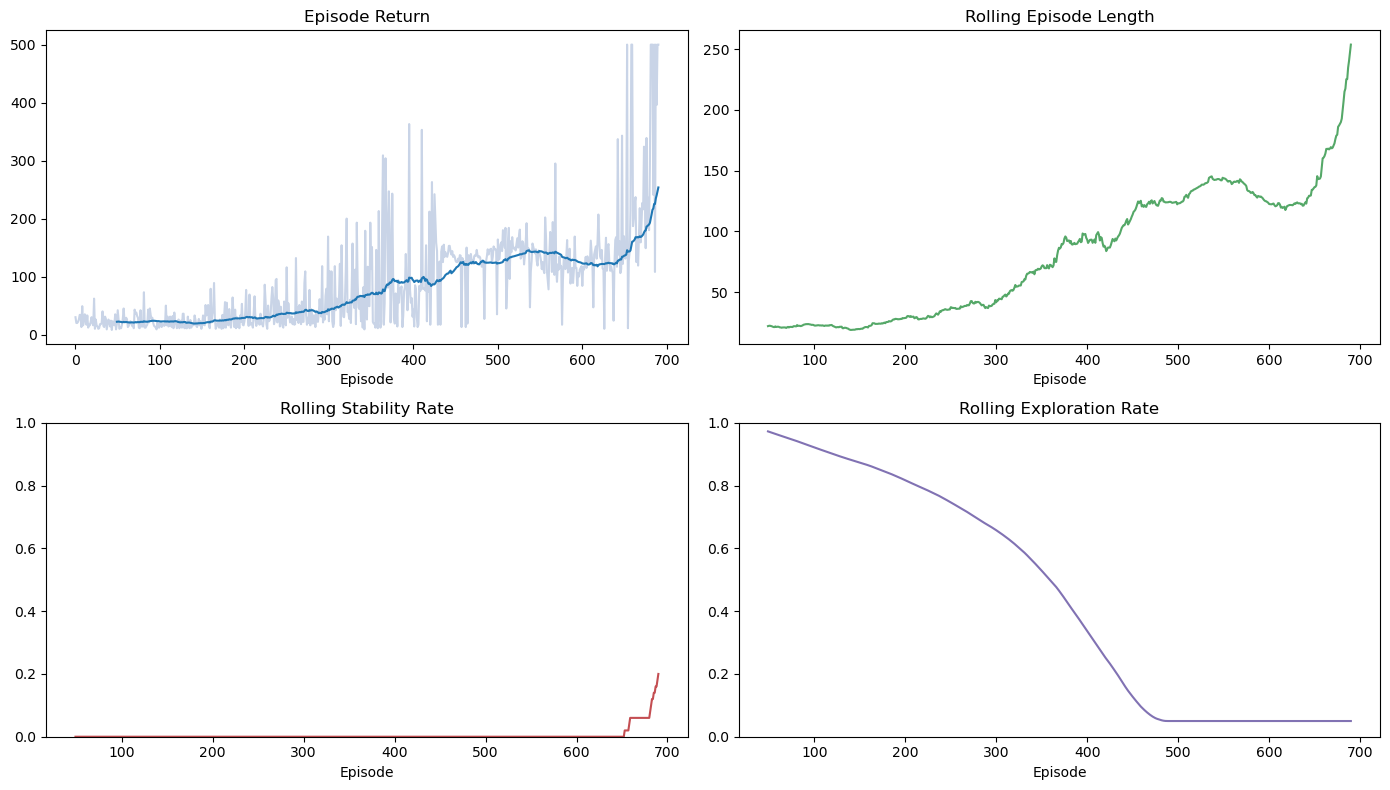

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(callback.episode_returns, alpha=0.30, color="#4c72b0")
axes[0, 0].plot(rolling_return, color="#1f77b4")
axes[0, 0].set_title("Episode Return")
axes[0, 0].set_xlabel("Episode")

axes[0, 1].plot(rolling_length, color="#55a868")
axes[0, 1].set_title("Rolling Episode Length")
axes[0, 1].set_xlabel("Episode")

axes[1, 0].plot(rolling_success, color="#c44e52")
axes[1, 0].set_title("Rolling Stability Rate")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(rolling_exploration, color="#8172b3")
axes[1, 1].set_title("Rolling Exploration Rate")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dqn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
def q_values_for_state(state):
    state_tensor = torch.tensor(state, dtype=torch.float32, device=model.device).unsqueeze(0)
    with torch.no_grad():
        q_values = model.q_net(state_tensor).cpu().numpy().squeeze(0)
    return q_values


def build_policy_slice(cart_position=0.0, cart_velocity=0.0):
    pole_angles = np.linspace(-0.209, 0.209, 41)
    pole_angular_velocities = np.linspace(-2.5, 2.5, 41)
    policy_map = np.zeros((len(pole_angles), len(pole_angular_velocities)), dtype=int)
    value_map = np.zeros((len(pole_angles), len(pole_angular_velocities)), dtype=float)

    for i, pole_angle in enumerate(pole_angles):
        for j, pole_ang_vel in enumerate(pole_angular_velocities):
            state = np.array([cart_position, cart_velocity, pole_angle, pole_ang_vel], dtype=np.float32)
            q_vals = q_values_for_state(state)
            policy_map[i, j] = int(np.argmax(q_vals))
            value_map[i, j] = float(np.max(q_vals))

    return pole_angles, pole_angular_velocities, policy_map, value_map


pole_angles, pole_ang_vels, policy_map, value_map = build_policy_slice()


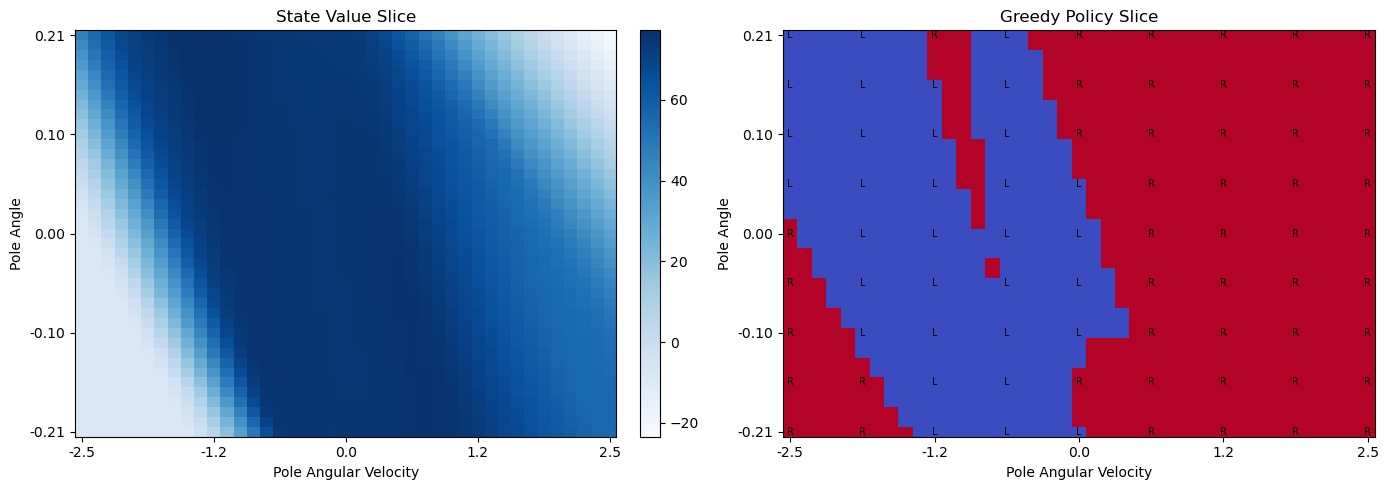

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(value_map, origin="lower", aspect="auto", cmap="Blues")
axes[0].set_title("State Value Slice")
axes[0].set_xlabel("Pole Angular Velocity")
axes[0].set_ylabel("Pole Angle")
axes[0].set_xticks(np.linspace(0, len(pole_ang_vels) - 1, 5, dtype=int))
axes[0].set_xticklabels([f"{pole_ang_vels[idx]:.1f}" for idx in np.linspace(0, len(pole_ang_vels) - 1, 5, dtype=int)])
axes[0].set_yticks(np.linspace(0, len(pole_angles) - 1, 5, dtype=int))
axes[0].set_yticklabels([f"{pole_angles[idx]:.2f}" for idx in np.linspace(0, len(pole_angles) - 1, 5, dtype=int)])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(policy_map, origin="lower", aspect="auto", cmap="coolwarm", vmin=0, vmax=1)
axes[1].set_title("Greedy Policy Slice")
axes[1].set_xlabel("Pole Angular Velocity")
axes[1].set_ylabel("Pole Angle")
axes[1].set_xticks(np.linspace(0, len(pole_ang_vels) - 1, 5, dtype=int))
axes[1].set_xticklabels([f"{pole_ang_vels[idx]:.1f}" for idx in np.linspace(0, len(pole_ang_vels) - 1, 5, dtype=int)])
axes[1].set_yticks(np.linspace(0, len(pole_angles) - 1, 5, dtype=int))
axes[1].set_yticklabels([f"{pole_angles[idx]:.2f}" for idx in np.linspace(0, len(pole_angles) - 1, 5, dtype=int)])

for i in range(0, len(pole_angles), 5):
    for j in range(0, len(pole_ang_vels), 5):
        axes[1].text(j, i, "L" if policy_map[i, j] == 0 else "R", ha="center", va="center", color="black", fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dqn_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
eval_env = gym.make(ENV_ID)
eval_returns = []
eval_lengths = []
eval_successes = []

for episode in tqdm(range(EVAL_EPISODES), desc="Policy evaluation"):
    obs, info = eval_env.reset(seed=SEED + 20000 + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        total_reward += reward
        if terminated or truncated:
            episode_length = step + 1
            break
    else:
        episode_length = MAX_STEPS

    eval_returns.append(total_reward)
    eval_lengths.append(episode_length)
    eval_successes.append(int(episode_length >= SUCCESS_THRESHOLD))

eval_env.close()


Policy evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

In [10]:
eval_avg_return = float(np.mean(eval_returns))
eval_return_std = float(np.std(eval_returns))
eval_avg_length = float(np.mean(eval_lengths))
eval_success_rate = float(np.mean(eval_successes))

metrics = pd.DataFrame(
    {
        "metric": [
            "device",
            "total_timesteps",
            "recent_episode_return_last_50",
            "recent_episode_length_last_50",
            "recent_stability_rate_last_50",
            "evaluation_average_return",
            "evaluation_return_std",
            "evaluation_average_length",
            "evaluation_stability_rate",
        ],
        "value": [
            DEVICE,
            TOTAL_TIMESTEPS,
            float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0,
            float(episode_length_series.tail(50).mean()) if len(episode_length_series) > 0 else 0.0,
            float(episode_success_series.tail(50).mean()) if len(episode_success_series) > 0 else 0.0,
            eval_avg_return,
            eval_return_std,
            eval_avg_length,
            eval_success_rate,
        ],
    }
)
metrics


,metric,value
0,device,cpu
1,total_timesteps,60000
2,recent_episode_return_last_50,253.68
3,recent_episode_length_last_50,253.68
4,recent_stability_rate_last_50,0.2
5,evaluation_average_return,481.86
6,evaluation_return_std,88.878009
7,evaluation_average_length,481.86
8,evaluation_stability_rate,0.96


In [11]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 30000 + rollout_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = rollout_env.step(int(action))
        total_reward += reward

        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.append(final_frame)
            rollout_summaries.append(
                {
                    "rollout_index": rollout_idx + 1,
                    "seed": SEED + 30000 + rollout_idx,
                    "total_reward": total_reward,
                    "steps": step + 1,
                }
            )
            break

    rollout_env.close()
    if frames:
        imageio.mimsave(RESULTS_DIR / f"dqn_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)


In [12]:
metrics.to_csv(RESULTS_DIR / "dqn_metrics.csv", index=False)
pd.DataFrame({"episode_return": callback.episode_returns}).to_csv(RESULTS_DIR / "dqn_episode_returns.csv", index=False)
pd.DataFrame({"episode_length": callback.episode_lengths}).to_csv(RESULTS_DIR / "dqn_episode_lengths.csv", index=False)
pd.DataFrame({"episode_success": callback.episode_successes}).to_csv(RESULTS_DIR / "dqn_episode_successes.csv", index=False)
pd.DataFrame({"evaluation_return": eval_returns, "evaluation_length": eval_lengths, "evaluation_success": eval_successes}).to_csv(RESULTS_DIR / "dqn_eval_results.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "dqn_rollout_summary.csv", index=False)

print(f"Recent average return (last 50): {episode_return_series.tail(50).mean():.2f}")
print(f"Recent average length (last 50): {episode_length_series.tail(50).mean():.2f}")
print(f"Recent stability rate (last 50): {episode_success_series.tail(50).mean():.4f}")
print(f"Evaluation average return: {eval_avg_return:.2f}")
print(f"Evaluation average length: {eval_avg_length:.2f}")
print(f"Evaluation stability rate: {eval_success_rate:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Recent average return (last 50): 253.68
Recent average length (last 50): 253.68
Recent stability rate (last 50): 0.2000
Evaluation average return: 481.86
Evaluation average length: 481.86
Evaluation stability rate: 0.9600
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/07-cartpole-dqn/results


## 结果解读

训练完成后，重点观察以下内容：

- episode return 和 episode length 是否持续改善
- 稳定率是否从接近随机水平明显提升
- 策略切片图上是否出现连贯的左右控制边界
- 固定评估阶段是否能稳定接近回合上限

如果这些现象都成立，就说明 `DQN` 已经在连续状态空间中学到了有效的平衡控制策略。这个实验最重要的意义在于，它把经典价值学习从表格环境自然推进到了神经网络近似场景。
